# Comparação exploratória ARIMA com BTC-USD

Ordens fixadas antes dos ajustes: (0,1,0), (1,1,0), (0,1,1), (1,1,1), sem drift. Mesmos cortes e métricas do Prophet. O teste Prophet já foi visto, então esta etapa é exploratória. Seleção ARIMA usa somente validação. [Protocolo](protocolo-arima.md). Execute a comparação Prophet primeiro para gerar as previsões de referência.

Implementação compartilhada pelo notebook e terminal: `train_arima.py`.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if root.name == "training":
    root = root.parent
sys.path.insert(0, str(root / "training"))
from train_arima import run_experiment
report = run_experiment(root)


Importing plotly failed. Interactive plots will not work.


Validação ARIMA 3y, ordem (0, 1, 0)


Validação ARIMA 3y, ordem (1, 1, 0)


Validação ARIMA 3y, ordem (0, 1, 1)


Validação ARIMA 3y, ordem (1, 1, 1)


...

Validação ARIMA 12y, ordem (1, 1, 0)


Validação ARIMA 12y, ordem (0, 1, 1)


Validação ARIMA 12y, ordem (1, 1, 1)


Teste ARIMA 3y, ordem (0, 1, 0)


Teste ARIMA 12y, ordem (0, 1, 0)


In [2]:
import pandas as pd
display(pd.DataFrame(report["test_comparison"]).T)
print("Escolha por validação:", report["selection"])

,mae_usd,rmse_usd,smape_percent
"ARIMA 3y (0, 1, 0)",8707.092795,11875.248060,12.094752
"ARIMA 12y (0, 1, 0)",8707.092795,11875.248060,12.094752
Prophet 3y,16347.510002,21582.530130,25.060251
Prophet 12y,28836.894628,29900.361685,33.771904
Último fechamento,8707.092795,11875.248060,12.094752


Escolha por validação: {'selected_window': '3y', 'orders_by_window': {'3y': [0, 1, 0], '12y': [0, 1, 0]}, 'validation_mae_usd': {'3y': 6613.447916666667, '12y': 6613.447916666667}, 'selected_at_utc': '2026-10-05T18:39:23.828536+00:00', 'criterion': 'MAE de validação; empates conforme protocolo-arima.md'}


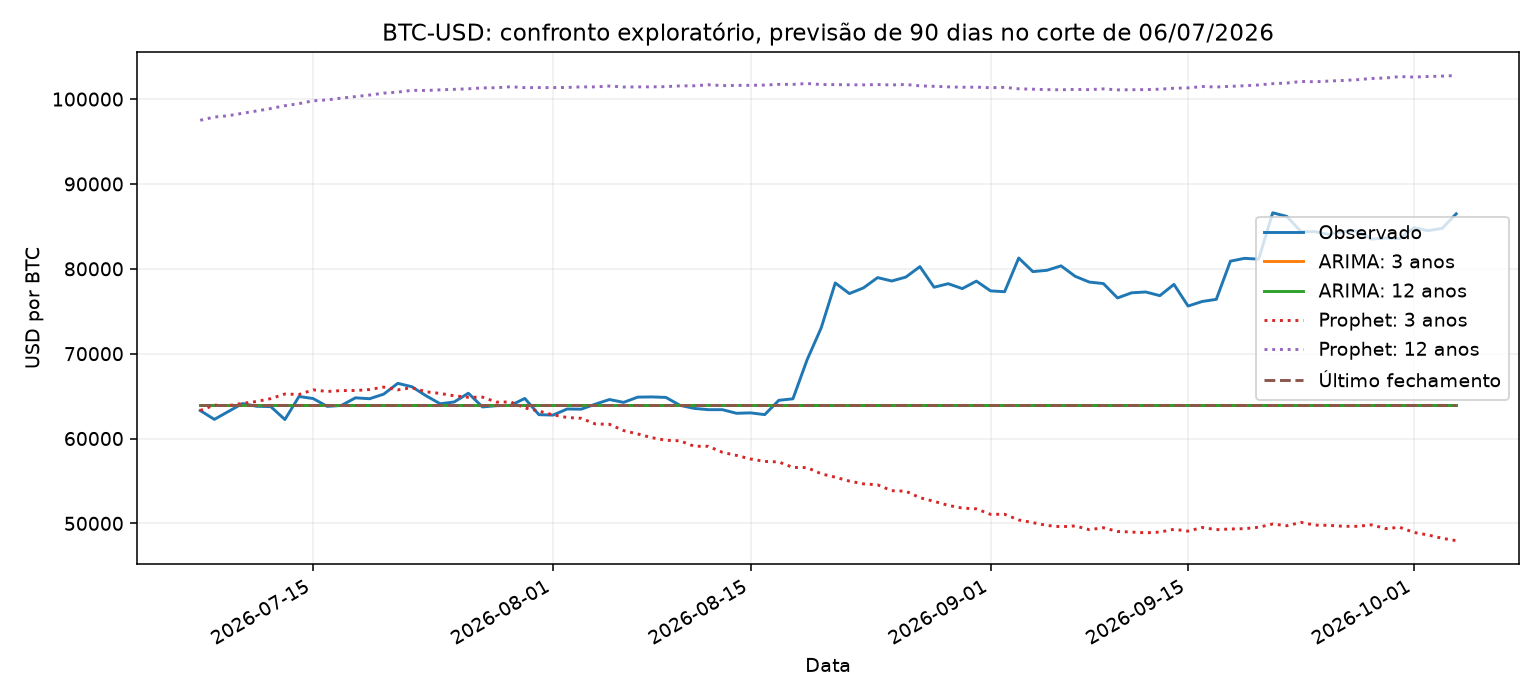

In [3]:
from IPython.display import Image, display
display(Image(filename=str(root / "reports/arima-teste.png")))

O JSON ARIMA é separado do artefato Prophet servido pelo backend. A reconstrução pelos parâmetros reproduz as previsões, e o reajuste final não possui avaliação independente. A previsão de 90 dias feita de uma vez não representa atualização diária.